In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


# **OU Training for Digits**

## Imports

In [ ]:
#%load_ext autoreload
#%autoreload 2

import torch
import numpy as np

from tqdm.auto import trange

from torch.utils.data import DataLoader, Subset
from torch.optim import Adam
import torch
from torch.utils.data import (
    DataLoader,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Resize, Compose


import sys, os
sys.path.append(os.path.abspath("../"))

import src.diffusion_process as dfp
from src.diffusion_utilities import plot_image_grid
from src.ou_schedules import make_ou_process_functions
from src.score_model import ScoreNet

## Basic configuration

In [ ]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

_ = torch.manual_seed(123)

Device: cuda
Number of threads: 6


## Load dataset

In [ ]:
# Addd Resize((32, 32)) to ensure dimensions are powers of 2
transform = Compose([
    Resize((32, 32)),
    ToTensor(),
    Normalize((0.5,), (0.5,))
])

# Dataset MNIST
data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform,
)

# Create a subset dataset composed only of one digit
# digit = 3
# indices_digit = torch.where(data.targets == digit)[0]
# data_train = Subset(data, indices_digit)

# Use the complete MNIST training dataset: all digits from 0 to 9
data_train = data

# Create a DataLoader for the training dataset
data_loader = DataLoader(
    data_train,
    batch_size=32,
    shuffle=True,
    num_workers=n_threads,
)

print(type(data_train))
print("Number of images:", len(data_train))

<class 'torchvision.datasets.mnist.MNIST'>
Number of images: 60000


## Dataset visualization

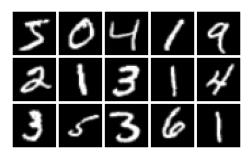

In [ ]:
# Visualize training images
n_rows = 3
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

## Model creation

In [ ]:
schedule_name = "cosine"
sched = make_ou_process_functions(schedule_name)

drift_coeff = sched["drift_coefficient"]
diffusion_coeff = sched["diffusion_coefficient"]
mu_t = sched["mu_t"]
sigma_t = sched["sigma_t"]

# Define the Gaussian Diffusion Process
diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient=drift_coeff,
    diffusion_coefficient=diffusion_coeff,
    mu_t=mu_t,
    sigma_t=sigma_t
)

# Define the score model
score_model = ScoreNet(
    marginal_prob_std=sigma_t,
    in_channels=1,
    out_channels=1
).to(device)

## Training

In [ ]:
learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 500

PROJECT_ROOT = "/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models"

checkpoint_dir = f"{PROJECT_ROOT}/checkpoints/mnist_all_ou_{schedule_name}"
os.makedirs(checkpoint_dir, exist_ok=True)

tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    tqdm_epoch.set_description(
        "Average Loss: {:5f}".format(avg_loss / num_items)
    )

    if (epoch + 1) in [10, 20, 50, 100, 200, 500]:
        path = f"{checkpoint_dir}/checkpoint_ou_{schedule_name}_epoch{epoch+1}.pth"
        torch.save(score_model.state_dict(), path)
        print(f"Saved: {path}")

  0%|          | 0/500 [00:00<?, ?it/s]

Saved: ../checkpoints/mnist_all_ou_cosine/checkpoint_ou_cosine_epoch10.pth
Saved: ../checkpoints/mnist_all_ou_cosine/checkpoint_ou_cosine_epoch20.pth
Saved: ../checkpoints/mnist_all_ou_cosine/checkpoint_ou_cosine_epoch50.pth
Saved: ../checkpoints/mnist_all_ou_cosine/checkpoint_ou_cosine_epoch100.pth
Saved: ../checkpoints/mnist_all_ou_cosine/checkpoint_ou_cosine_epoch200.pth
Saved: ../checkpoints/mnist_all_ou_cosine/checkpoint_ou_cosine_epoch500.pth
